In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hospital Overflow + Unmet Care Simulation and Analysis

This is essentially just a crude model with some simulations and subsequent analysis of hospital overflow and unmet care needs over a specified period. It models patient arrivals, hospital capacity, and the resulting overflow and unmet care statistics, we can modify this in many ways if we want.

- I kind of need to triple check but I feel like this covers most of the things that Dr. Larremore was saying in his feedback.

- The implementation sets up a SIXHRD compartmental model with hospital capacity contraints.

- It uses Euler's method to simulate the system with a time step of ```dt``` over a period of ```Tmax``` days.

- It implements the smooth Hill function for modeling hospital admission gating.

- It tracks key metrics such as total overflow and unmet care needs.

- It includes vaccine effects using a leaky model when coverage $\gt 0$.
- It visualizes the results of the epidemic dynamics, hospital capacity utilization, overflow, and summary statistics.

# The Hospital Overflow Model

In [2]:
def simulate_hospital_model(beta, sigma, eta, gamma_I, mu_I, gamma_X, mu_X, 
                           gamma_H, mu_H, theta_X, theta_H, hosp_capacity, 
                           hill_coef, coverage, VE, N, S=None, I=None, X=None, 
                           H=None, R=None, D=None, Tmax=200, time_step=0.1):
    """
    Simulate SIXHRD hospital model with capacity constraints.
    """
    K = hosp_capacity
    n = hill_coef
    dt = time_step
    
    # Initial conditions - use parameters if provided, else defaults
    if S is None:
        S = N - 10
    if I is None:
        I = 10
    if X is None:
        X = 0
    if H is None:
        H = 0
    if R is None:
        R = 0
    if D is None:
        D = 0
    
    # storage arrays
    times = []
    S_vals, I_vals, X_vals, H_vals, R_vals, D_vals = [], [], [], [], [], []
    overflow_vals = []
    unmet_vals = []
    cum_overflow = 0
    cum_unmet = 0
    
    # vaccine effect
    eff_beta = beta * (1 - coverage * VE)
    
    # loop across time
    t = 0
    while t <= Tmax:
        # store values at each time step
        times.append(t)
        S_vals.append(S)
        I_vals.append(I)
        X_vals.append(X)
        H_vals.append(H)
        R_vals.append(R)
        D_vals.append(D)
        
        # Force of infection
        lambda_foi = eff_beta * (I + theta_X*X + theta_H*H) / N
        new_inf = lambda_foi * S
        
        # Capacity gate (smooth Hill function)
        if K > 0:
            g = 1 / (1 + (H/K)**n)
        else:
            g = 0
        admit = eta * X * g
        
        # The ODEs
        dS = -new_inf
        dI = new_inf - (gamma_I + mu_I + sigma) * I
        dX = sigma*I - (gamma_X + mu_X) * X - admit
        dH = admit - (gamma_H + mu_H) * H
        dR = gamma_I*I + gamma_X*X + gamma_H*H
        dD = mu_I*I + mu_X*X + mu_H*H
        
        # Euler update
        S += dS * dt
        I += dI * dt
        X += dX * dt
        H += dH * dt
        R += dR * dt
        D += dD * dt
        
        # Prevent negative values
        S = max(0, S)
        I = max(0, I)
        X = max(0, X)
        H = max(0, H)
        R = max(0, R)
        D = max(0, D)
        
        # Track metrics
        overflow = max(0, H - K)
        cum_overflow += overflow * dt
        overflow_vals.append(overflow)
        
        unmet_care = eta*X - admit
        unmet_vals.append(unmet_care)
        cum_unmet += max(0, unmet_care) * dt
        
        t += dt
        
    return times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cum_overflow, cum_unmet, unmet_vals

# Plotting Functionality:

In [3]:
def plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, 
                                   D_vals, overflow_vals, cum_overflow, cum_unmet, 
                                   hosp_capacity, N):
    """Plot simulation results."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Compartments over time
    axes[0, 0].plot(times, S_vals, label='S (Susceptible)')
    axes[0, 0].plot(times, I_vals, label='I (Infected)')
    axes[0, 0].plot(times, X_vals, label='X (Needs care)')
    axes[0, 0].plot(times, H_vals, label='H (Hospitalized)')
    axes[0, 0].plot(times, R_vals, label='R (Recovered)')
    axes[0, 0].plot(times, D_vals, label='D (Deaths)')
    axes[0, 0].set_xlabel('Time (days)')
    axes[0, 0].set_ylabel('Population')
    axes[0, 0].legend()
    axes[0, 0].set_title('Epidemic Dynamics')
    axes[0, 0].grid(True, alpha=0.3)

    # Hospital capacity
    axes[0, 1].plot(times, H_vals, label='Hospitalized', color='red')
    axes[0, 1].axhline(y=hosp_capacity, color='black', linestyle='--', 
                       label=f'Capacity (K={hosp_capacity})')
    axes[0, 1].fill_between(times, 0, hosp_capacity, alpha=0.2, 
                            color='green', label='Available capacity')
    axes[0, 1].set_xlabel('Time (days)')
    axes[0, 1].set_ylabel('Hospital beds')
    axes[0, 1].legend()
    axes[0, 1].set_title('Hospital Capacity Utilization')
    axes[0, 1].grid(True, alpha=0.3)

    # Overflow
    axes[1, 0].plot(times, overflow_vals, color='red')
    axes[1, 0].set_xlabel('Time (days)')
    axes[1, 0].set_ylabel('Overflow patients')
    axes[1, 0].set_title(f'Hospital Overflow (Cumulative: {cum_overflow:.1f} patient-days)')
    axes[1, 0].grid(True, alpha=0.3)

    # Summary statistics
    axes[1, 1].axis('off')
    attack_rate = (R_vals[-1] + D_vals[-1]) / N * 100
    summary_text = f"""
  Summary Statistics:
  ━━━━━━━━━━━━━━━━━━━━━━
  Peak Hospitalized: {max(H_vals):.1f}
  Total Deaths: {D_vals[-1]:.1f}
  Total Recovered: {R_vals[-1]:.1f}
  Attack Rate: {attack_rate:.1f}%

  Cumulative Overflow: {cum_overflow:.1f} patient-days
  Cumulative Unmet Care: {cum_unmet:.1f} patient-days

  Final Population:
    S: {S_vals[-1]:.1f}
    I: {I_vals[-1]:.1f}
    X: {X_vals[-1]:.1f}
    H: {H_vals[-1]:.1f}
    R: {R_vals[-1]:.1f}
    D: {D_vals[-1]:.1f}
  """

    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                    verticalalignment='center')

    plt.tight_layout()
    plt.show()

    print(f"\nSimulation complete!")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: {hosp_capacity})")
    print(f"Cumulative overflow: {cum_overflow:.1f} patient-days")
    print(f"Cumulative unmet care: {cum_unmet:.1f} patient-days")

# Here we simulate over values of Beta and observe hospital overflow and unmet care needs.

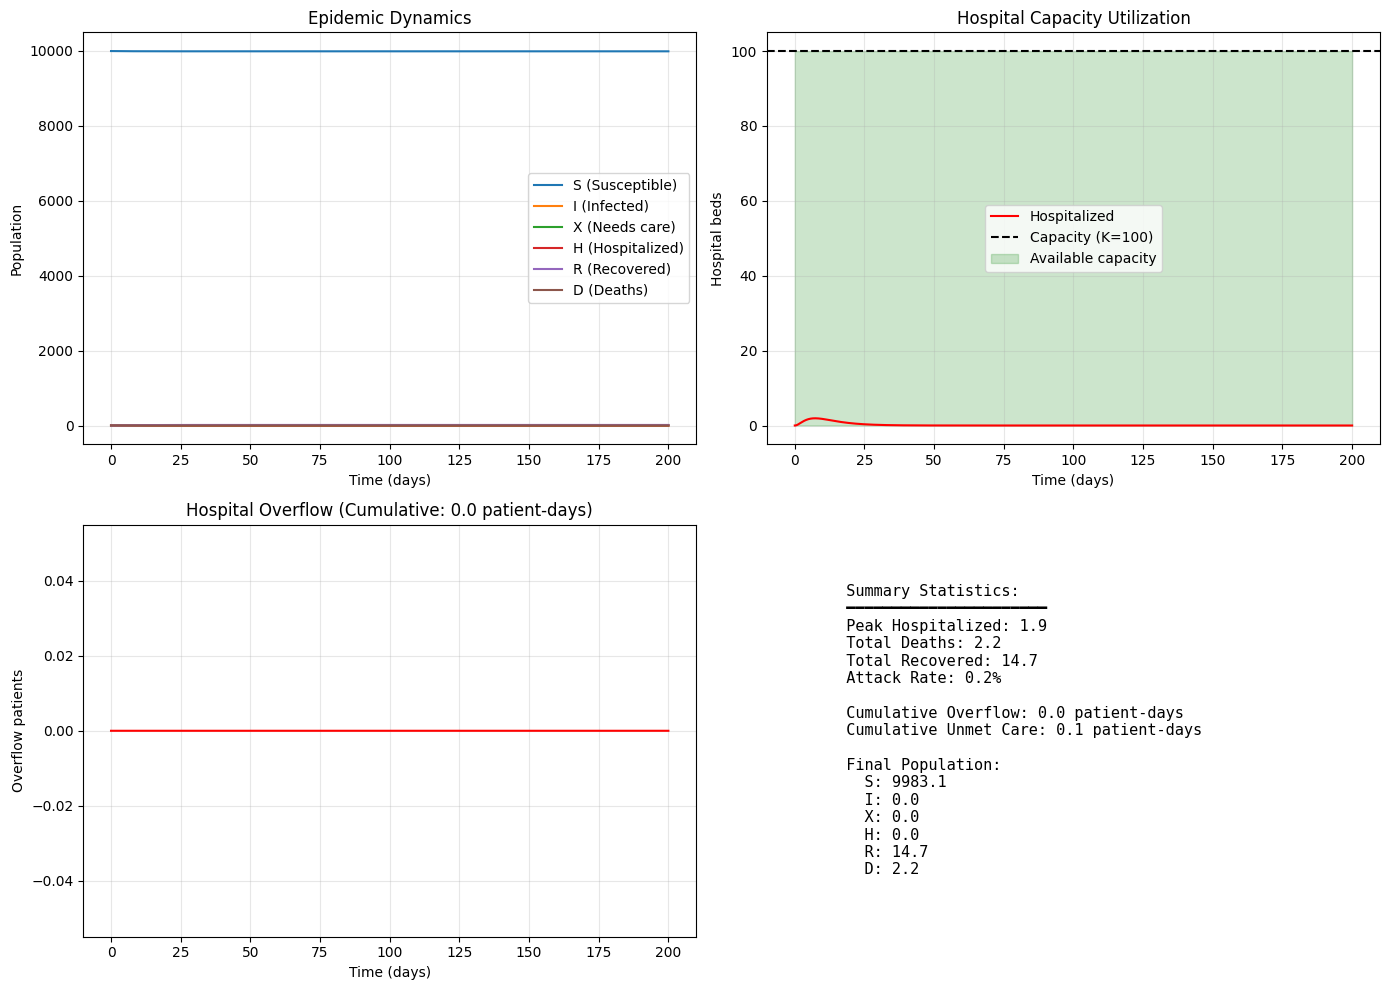


Simulation complete!
Total deaths: 2
Peak hospital occupancy: 1.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days
Cumulative unmet care: 0.1 patient-days

Beta: 0.1
Total deaths: 2
Peak hospital occupancy: 1.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days


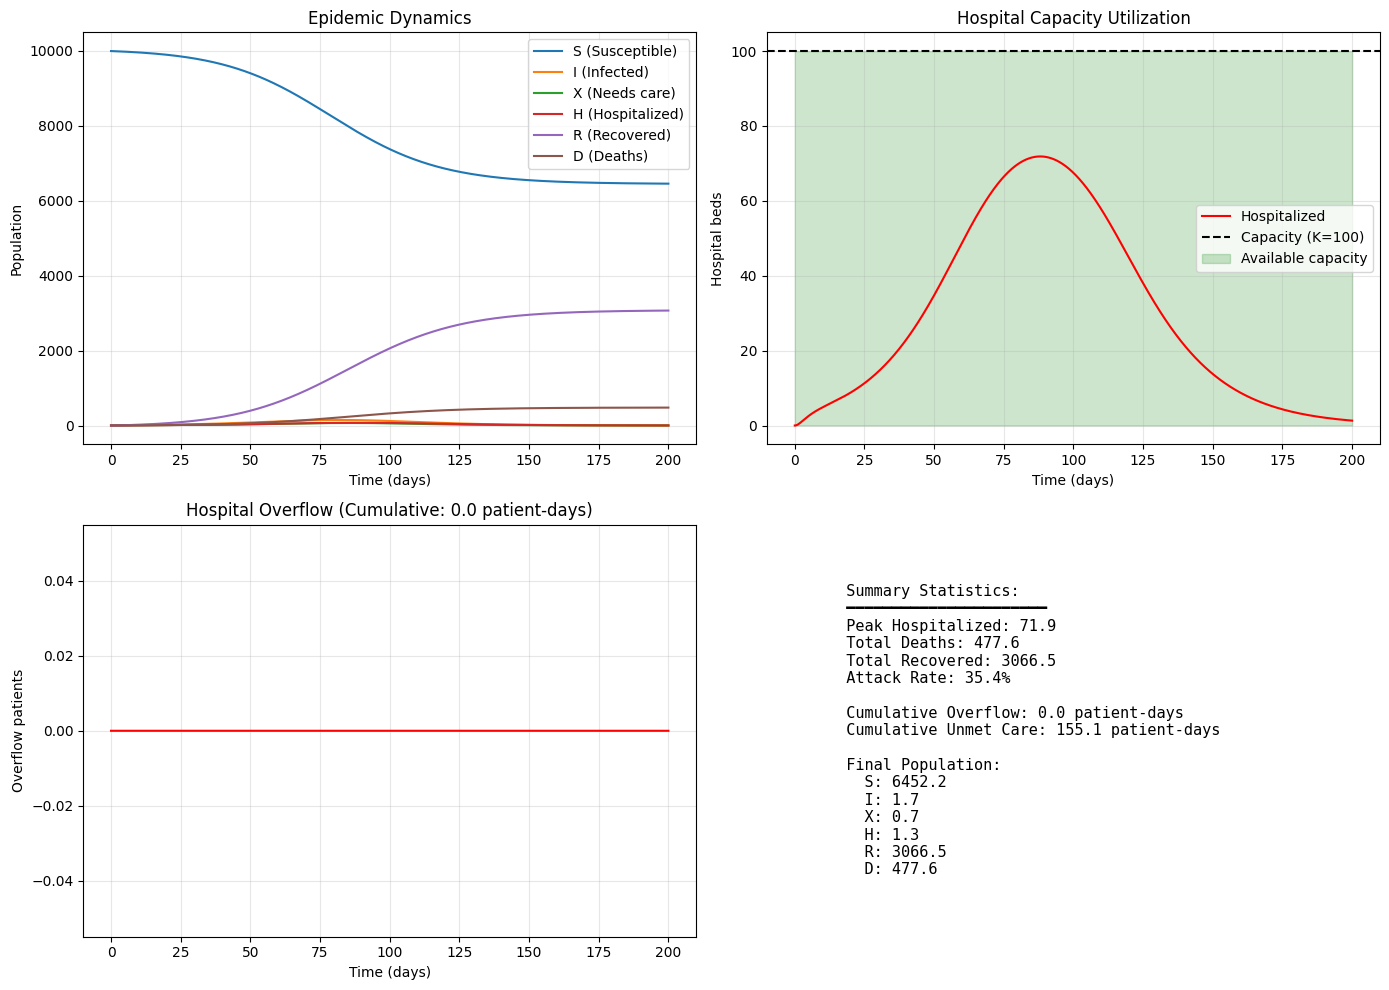


Simulation complete!
Total deaths: 478
Peak hospital occupancy: 71.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days
Cumulative unmet care: 155.1 patient-days

Beta: 0.3
Total deaths: 478
Peak hospital occupancy: 71.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days


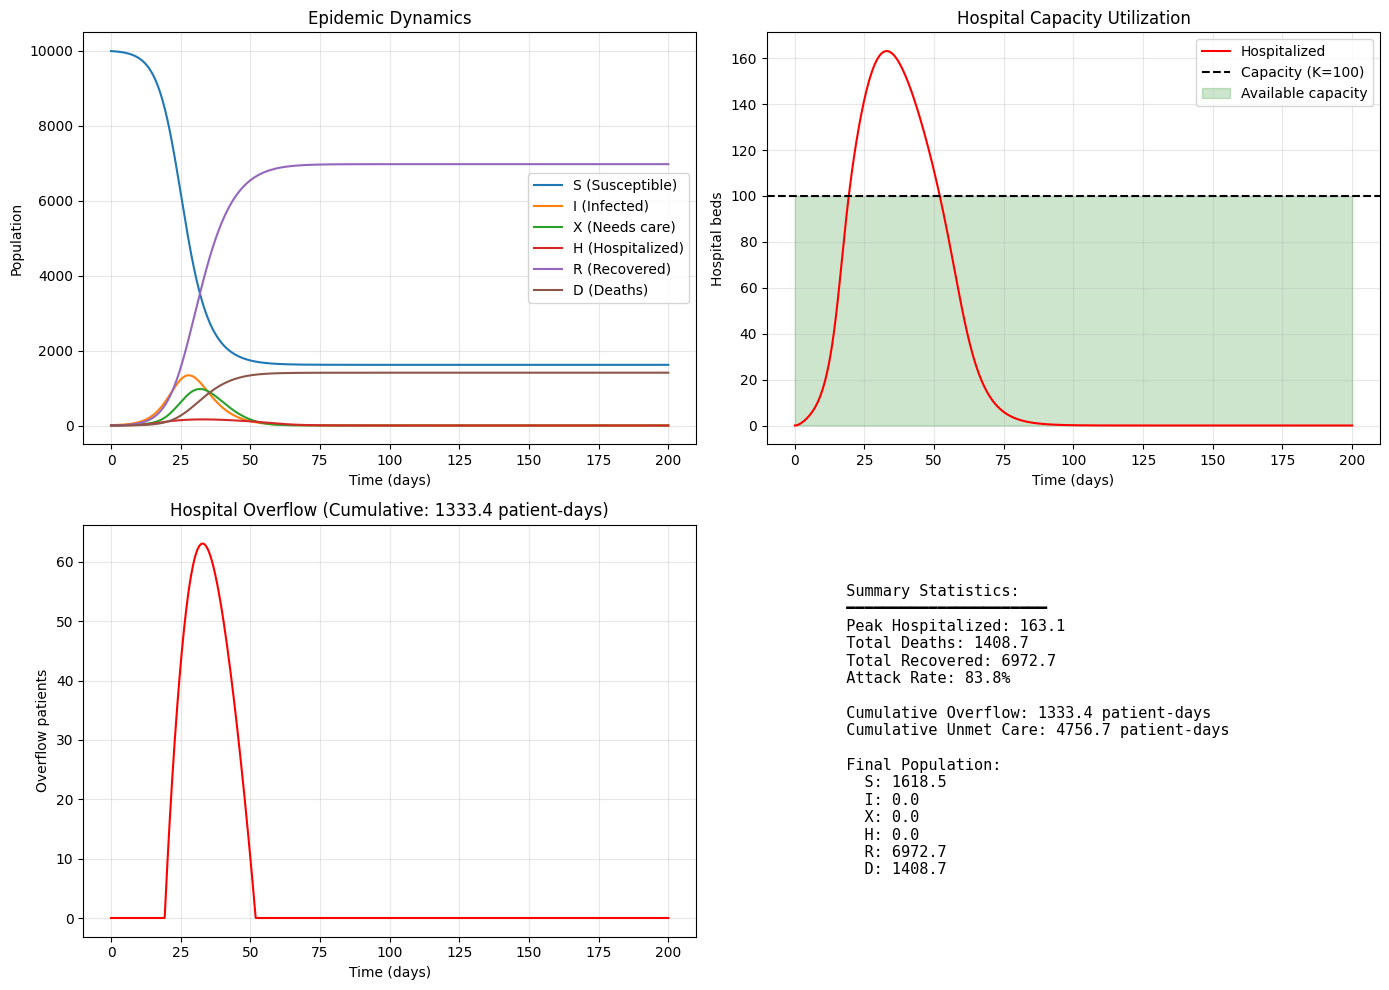


Simulation complete!
Total deaths: 1409
Peak hospital occupancy: 163.1 (Capacity: 100)
Cumulative overflow: 1333.4 patient-days
Cumulative unmet care: 4756.7 patient-days

Beta: 0.5
Total deaths: 1409
Peak hospital occupancy: 163.1 (Capacity: 100)
Cumulative overflow: 1333.4 patient-days


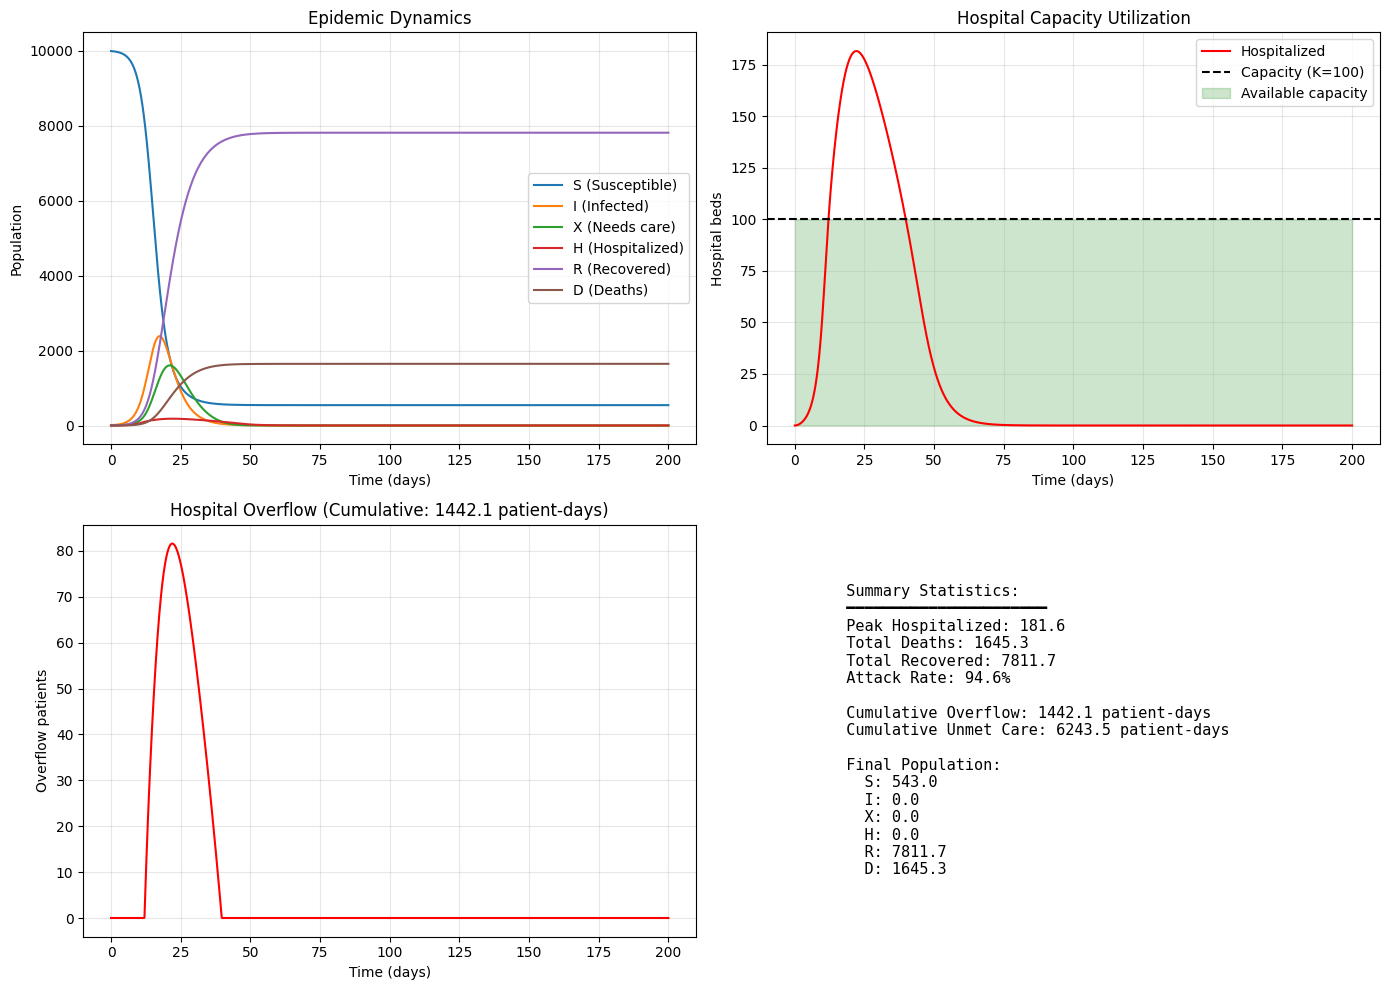


Simulation complete!
Total deaths: 1645
Peak hospital occupancy: 181.6 (Capacity: 100)
Cumulative overflow: 1442.1 patient-days
Cumulative unmet care: 6243.5 patient-days

Beta: 0.7
Total deaths: 1645
Peak hospital occupancy: 181.6 (Capacity: 100)
Cumulative overflow: 1442.1 patient-days


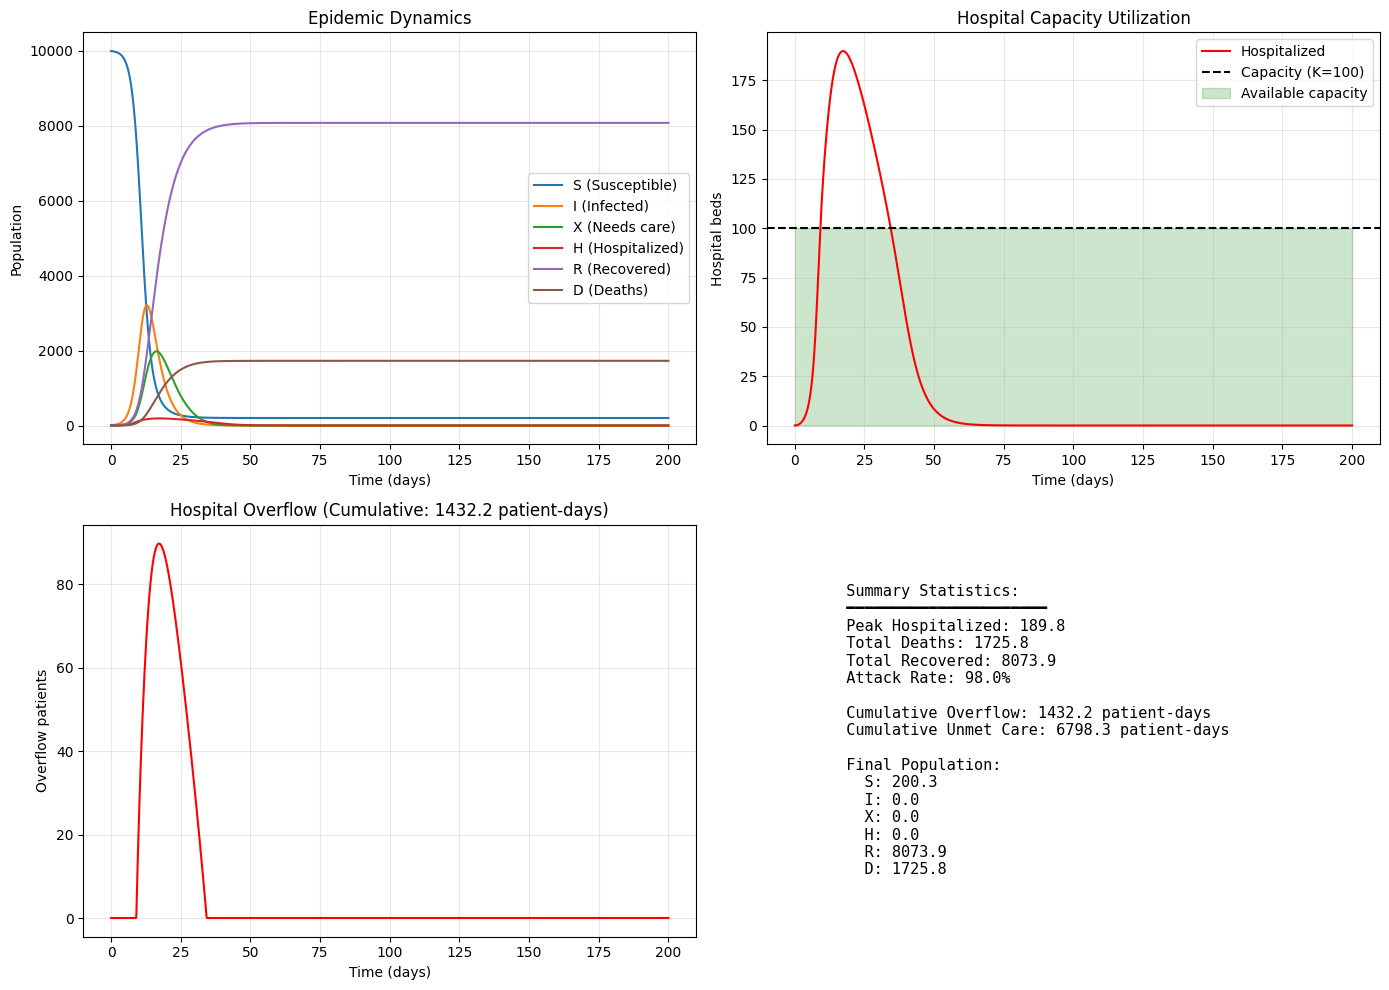


Simulation complete!
Total deaths: 1726
Peak hospital occupancy: 189.8 (Capacity: 100)
Cumulative overflow: 1432.2 patient-days
Cumulative unmet care: 6798.3 patient-days

Beta: 0.9
Total deaths: 1726
Peak hospital occupancy: 189.8 (Capacity: 100)
Cumulative overflow: 1432.2 patient-days


In [4]:
beta_vals = [0.1, 0.3, 0.5, 0.7, 0.9]

for beta in beta_vals:
    times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, unmet_care = simulate_hospital_model(
        beta=beta,
        sigma=0.2,
        eta=0.3,
        gamma_I=0.1,
        mu_I=0.01,
        gamma_X=0.15,
        mu_X=0.05,
        gamma_H=0.2,
        mu_H=0.02,
        theta_X=0.5,
        theta_H=0.3,
        hosp_capacity=100,
        hill_coef=4,
        coverage=0.1,
        VE=0.7,
        N=10000,
        S=None,
        I=None,
        X=None,
        H=None,
        R=None,
        D=None,
        Tmax=200,
        time_step=0.1
    )
    
    plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, hosp_capacity=100, N = 10000)
    
    
    print(f"\nBeta: {beta}")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: 100)")
    print(f"Cumulative overflow: {cumulative_overflow:.1f} patient-days")